Avaliação contínua 04

Regressão com fórmulas dadas em aula

In [9]:
install.packages("ggplot2")
library(ggplot2)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [10]:
data <- read.csv("taylor_swift_spotify.csv", header = TRUE)

tempo <- data$tempo
x <- as.array(tempo)
danceability <- data$danceability
y <- as.array(danceability)

In [11]:
data

X,name,album,release_date,track_number,id,uri,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms
<int>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
0,Welcome To New York (Taylor's Version),1989 (Taylor's Version) [Deluxe],2023-10-27,1,4WUepByoeqcedHoYhSNHRt,spotify:track:4WUepByoeqcedHoYhSNHRt,0.009420,0.757,0.610,3.66e-05,0.3670,-4.840,0.0327,116.998,0.6850,70,212600
1,Blank Space (Taylor's Version),1989 (Taylor's Version) [Deluxe],2023-10-27,2,0108kcWLnn2HlH2kedi1gn,spotify:track:0108kcWLnn2HlH2kedi1gn,0.088500,0.733,0.733,0.00e+00,0.1680,-5.376,0.0670,96.057,0.7010,71,231833
2,Style (Taylor's Version),1989 (Taylor's Version) [Deluxe],2023-10-27,3,3Vpk1hfMAQme8VJ0SNRSkd,spotify:track:3Vpk1hfMAQme8VJ0SNRSkd,0.000421,0.511,0.822,1.97e-02,0.0899,-4.785,0.0397,94.868,0.3050,72,231000
3,Out Of The Woods (Taylor's Version),1989 (Taylor's Version) [Deluxe],2023-10-27,4,1OcSfkeCg9hRC2sFKB4IMJ,spotify:track:1OcSfkeCg9hRC2sFKB4IMJ,0.000537,0.545,0.885,5.59e-05,0.3850,-5.968,0.0447,92.021,0.2060,71,235800
4,All You Had To Do Was Stay (Taylor's Version),1989 (Taylor's Version) [Deluxe],2023-10-27,5,2k0ZEeAqzvYMcx9Qt5aClQ,spotify:track:2k0ZEeAqzvYMcx9Qt5aClQ,0.000656,0.588,0.721,0.00e+00,0.1310,-5.579,0.0317,96.997,0.5200,70,193289
5,Shake It Off (Taylor's Version),1989 (Taylor's Version) [Deluxe],2023-10-27,6,50yNTF0Od55qnHLxYsA5Pw,spotify:track:50yNTF0Od55qnHLxYsA5Pw,0.012100,0.636,0.808,2.18e-05,0.3590,-5.693,0.0729,160.058,0.9170,69,219209
6,I Wish You Would (Taylor's Version),1989 (Taylor's Version) [Deluxe],2023-10-27,7,3FxJDucHWdw6caWTKO5b23,spotify:track:3FxJDucHWdw6caWTKO5b23,0.003540,0.670,0.858,1.25e-05,0.0687,-6.528,0.0439,118.009,0.5390,69,207650
7,Bad Blood (Taylor's Version),1989 (Taylor's Version) [Deluxe],2023-10-27,8,7oZONwFiFIErZcXAtTu7FY,spotify:track:7oZONwFiFIErZcXAtTu7FY,0.036200,0.618,0.683,0.00e+00,0.3050,-6.438,0.1940,169.971,0.3630,68,211103
8,Wildest Dreams (Taylor's Version),1989 (Taylor's Version) [Deluxe],2023-10-27,9,27exgla7YBw9DUNNcTIpjy,spotify:track:27exgla7YBw9DUNNcTIpjy,0.043600,0.589,0.674,7.18e-05,0.1120,-7.480,0.0656,139.985,0.5140,69,220433


In [12]:
str(data)

'data.frame':	530 obs. of  18 variables:
 $ X               : int  0 1 2 3 4 5 6 7 8 9 ...
 $ name            : chr  "Welcome To New York (Taylor's Version)" "Blank Space (Taylor's Version)" "Style (Taylor's Version)" "Out Of The Woods (Taylor's Version)" ...
 $ album           : chr  "1989 (Taylor's Version) [Deluxe]" "1989 (Taylor's Version) [Deluxe]" "1989 (Taylor's Version) [Deluxe]" "1989 (Taylor's Version) [Deluxe]" ...
 $ release_date    : chr  "2023-10-27" "2023-10-27" "2023-10-27" "2023-10-27" ...
 $ track_number    : int  1 2 3 4 5 6 7 8 9 10 ...
 $ id              : chr  "4WUepByoeqcedHoYhSNHRt" "0108kcWLnn2HlH2kedi1gn" "3Vpk1hfMAQme8VJ0SNRSkd" "1OcSfkeCg9hRC2sFKB4IMJ" ...
 $ uri             : chr  "spotify:track:4WUepByoeqcedHoYhSNHRt" "spotify:track:0108kcWLnn2HlH2kedi1gn" "spotify:track:3Vpk1hfMAQme8VJ0SNRSkd" "spotify:track:1OcSfkeCg9hRC2sFKB4IMJ" ...
 $ acousticness    : num  0.00942 0.0885 0.000421 0.000537 0.000656 0.0121 0.00354 0.0362 0.0436 0.00196 ...
 $ danceabil

In [13]:
summary(data)

       X             name              album           release_date      
 Min.   :  0.0   Length:530         Length:530         Length:530        
 1st Qu.:132.2   Class :character   Class :character   Class :character  
 Median :264.5   Mode  :character   Mode  :character   Mode  :character  
 Mean   :264.5                                                           
 3rd Qu.:396.8                                                           
 Max.   :529.0                                                           
  track_number        id                uri             acousticness     
 Min.   : 1.00   Length:530         Length:530         Min.   :0.000184  
 1st Qu.: 5.00   Class :character   Class :character   1st Qu.:0.036250  
 Median :10.00   Mode  :character   Mode  :character   Median :0.165000  
 Mean   :11.18                                         Mean   :0.319247  
 3rd Qu.:15.00                                         3rd Qu.:0.653000  
 Max.   :46.00                        

Regressão com fórmulas dadas em aula:





In [14]:
n <- 529
somax <- sum(x[0:n])
somay <- sum(y[0:n])
somaxy <- sum(x[0:n] * y[0:n])
somaxquadrado <- sum(x[0:n]**2)
somayquadrado <- sum(y[0:n]**2)

In [15]:
r <- ((n * somaxy) - (somax * somay)) / sqrt((n * somaxquadrado - somax**2)*(n * somayquadrado - somay**2))
a <- ((n * somaxy) - (somax * somay)) / ((n * somaxquadrado) - (somax**2))
b <- (somay / n) - (a * (somax / n))

In [16]:
format_r <- format(r, digits = 2)
format_a <- format(a, digits = 3)
format_b <- format(b, digits = 3)

In [17]:
paste("Correlação:", format_r)
paste("Equação da reta Y =", format_a, "X +", format_b)

[1] "Correlação: -0.22"

[1] "Equação da reta Y = -0.000817 X + 0.685"

Diagrama de dispersão com reta

`geom_smooth()` using formula = 'y ~ x'


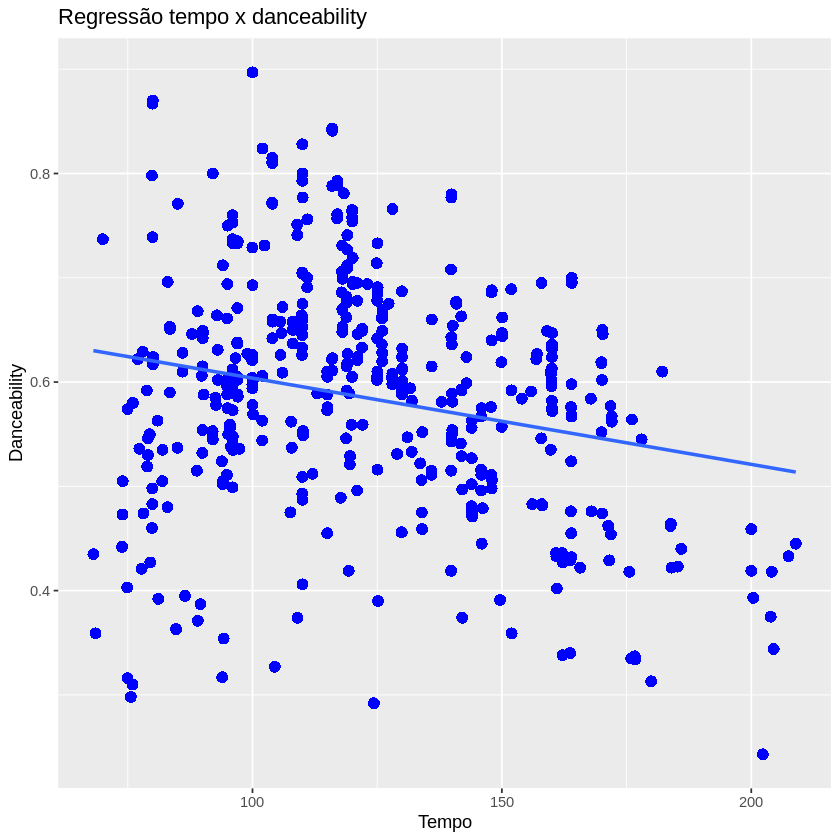

In [18]:
data <- data.frame(x = data$tempo, y = data$danceability)
ggplot(data, aes(x = x, y = y)) +
  labs(title = "Regressão tempo x danceability", x = "Tempo", y = "Danceability") +
    geom_point(color = "blue", size = 3, shape = 16) +
      geom_smooth(method = "lm", se = FALSE)


Regressão com pacotes prontos do R:

In [19]:
paste("Correlação:", cor(x,y))

[1] "Correlação: -0.219289476251298"

In [20]:
print("Equação de reta: ")
lm(formula = x ~ y)

[1] "Equação de reta: "



Call:
lm(formula = x ~ y)

Coefficients:
(Intercept)            y  
     156.37       -58.16  


`geom_smooth()` using formula = 'y ~ x'


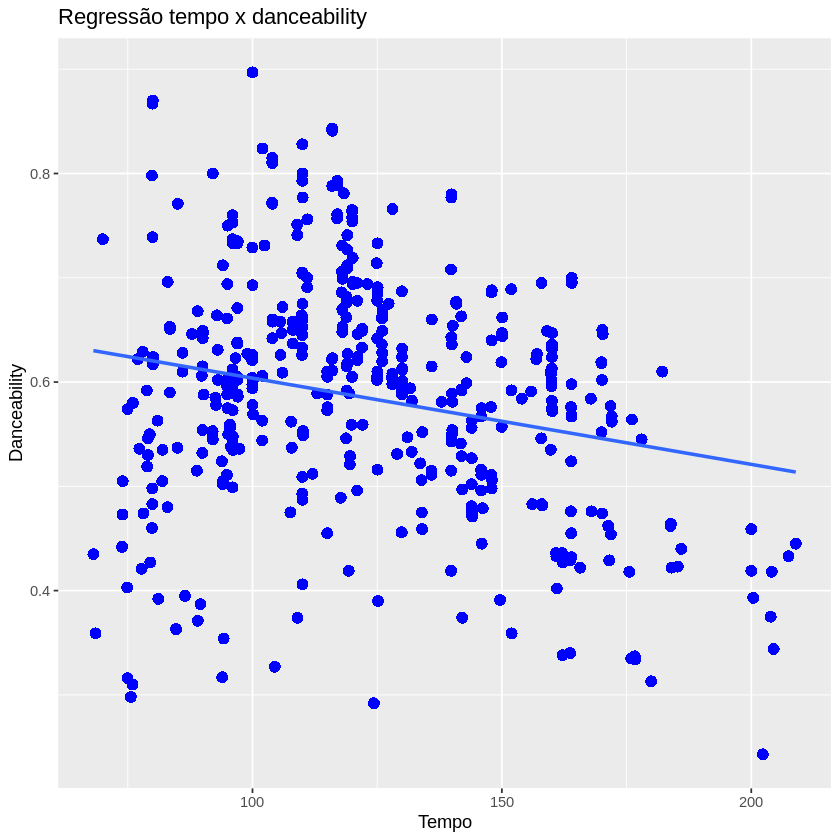

In [21]:
data <- data.frame(x = data$tempo, y = data$danceability)
ggplot(data, aes(x = x, y = y)) +
  labs(title = "Regressão tempo x danceability", x = "Tempo", y = "Danceability") +
    geom_point(color = "blue", size = 3, shape = 16) +
      geom_smooth(method = "lm", se = FALSE)
